In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/multimodal_emotion/data/labels.csv')
print(df.shape)
print(df['label'].value_counts())
df.head()

(4869, 4)
label
neutral     1921
positive    1731
negative    1217
Name: count, dtype: int64


,id,label,text,image_path
0,1,neutral,How I feel today #legday #jelly #aching #gym,data/raw/data/1.jpg
1,2,neutral,grattis min griskulting!!!???? va bara tvungen...,data/raw/data/2.jpg
2,3,neutral,RT @polynminion: The moment I found my favouri...,data/raw/data/3.jpg
3,4,positive,#escort We have a young and energetic team and...,data/raw/data/4.jpg
4,5,positive,"RT @chrisashaffer: Went to SSC today to be a ""...",data/raw/data/5.jpg


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

Usando: cuda


In [ ]:
class CaptionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
le = LabelEncoder()
labels = le.fit_transform(df['label'].tolist())
texts  = df['text'].tolist()
print(f"Clases: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_ds  = CaptionDataset(X_train, y_train, tokenizer)
test_ds   = CaptionDataset(X_test,  y_test,  tokenizer)
train_dl  = DataLoader(train_ds, batch_size=16, shuffle=True)
test_dl   = DataLoader(test_ds,  batch_size=32)

print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

Clases: ['negative' 'neutral' 'positive']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 3895 | Test: 974


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=len(le.classes_)).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_dl) // 5,
    num_training_steps=len(train_dl) * 3
)
print("Modelo listo")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo listo


In [ ]:
train_losses = []

for epoch in range(3):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_dl):
        optimizer.zero_grad()
        out = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['label'].to(device)
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()

        if i % 30 == 0:
            print(f"Epoch {epoch+1} | Batch {i}/{len(train_dl)} | Loss: {out.loss.item():.4f}")

    avg = total_loss / len(train_dl)
    train_losses.append(avg)
    print(f"\n>>> Epoch {epoch+1} completada — Loss media: {avg:.4f}\n")

Epoch 1 | Batch 0/244 | Loss: 1.0880
Epoch 1 | Batch 30/244 | Loss: 1.0040
Epoch 1 | Batch 60/244 | Loss: 1.0594
Epoch 1 | Batch 90/244 | Loss: 0.9726
Epoch 1 | Batch 120/244 | Loss: 0.8113
Epoch 1 | Batch 150/244 | Loss: 0.5192
Epoch 1 | Batch 180/244 | Loss: 0.4411
Epoch 1 | Batch 210/244 | Loss: 0.6313
Epoch 1 | Batch 240/244 | Loss: 1.0717

>>> Epoch 1 completada — Loss media: 0.8390

Epoch 2 | Batch 0/244 | Loss: 0.6569
Epoch 2 | Batch 30/244 | Loss: 0.6863
Epoch 2 | Batch 60/244 | Loss: 0.5493
Epoch 2 | Batch 90/244 | Loss: 0.4456
Epoch 2 | Batch 120/244 | Loss: 0.4560
Epoch 2 | Batch 150/244 | Loss: 0.6131
Epoch 2 | Batch 180/244 | Loss: 0.4497
Epoch 2 | Batch 210/244 | Loss: 0.5567
Epoch 2 | Batch 240/244 | Loss: 0.4758

>>> Epoch 2 completada — Loss media: 0.5475

Epoch 3 | Batch 0/244 | Loss: 0.2785
Epoch 3 | Batch 30/244 | Loss: 0.6035
Epoch 3 | Batch 60/244 | Loss: 0.7050
Epoch 3 | Batch 90/244 | Loss: 0.1907
Epoch 3 | Batch 120/244 | Loss: 0.4294
Epoch 3 | Batch 150/244 | 

In [ ]:
model.eval()
all_preds, all_probas = [], []

with torch.no_grad():
    for batch in test_dl:
        out   = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()
        all_probas.extend(probs.tolist())
        all_preds.extend(np.argmax(probs, axis=1).tolist())

print("=== BERT Fine-tuned ===")
print(classification_report(y_test, all_preds, target_names=le.classes_))
print(f"F1 macro: {f1_score(y_test, all_preds, average='macro'):.4f}")

=== BERT Fine-tuned ===
              precision    recall  f1-score   support

    negative       0.65      0.76      0.70       244
     neutral       0.76      0.66      0.70       384
    positive       0.76      0.77      0.77       346

    accuracy                           0.72       974
   macro avg       0.72      0.73      0.72       974
weighted avg       0.73      0.72      0.72       974

F1 macro: 0.7230


In [ ]:
import json, os

os.makedirs('/content/drive/MyDrive/multimodal_emotion/results', exist_ok=True)

results = {
    'f1_macro':      f1_score(y_test, all_preds, average='macro'),
    'probas':        all_probas,
    'train_losses':  train_losses,
    'label_encoder': le.classes_.tolist()
}

with open('/content/drive/MyDrive/multimodal_emotion/results/metrics_bert.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Guardado en Drive correctamente")

Guardado en Drive correctamente


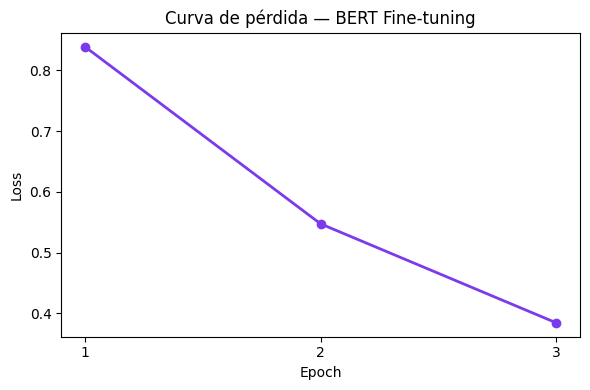

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, 4), train_losses, marker='o', color='#7c3aed', linewidth=2)
plt.title('Curva de pérdida — BERT Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks([1, 2, 3])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/multimodal_emotion/results/bert_loss_curve.png', dpi=150)
plt.show()